### Implement LSTM for Time Series Data

First, let's import the necessary libraries and generate some synthetic time series data.

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

# 1. Generate synthetic time series data
def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))  #   Wave 1
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20))  # Additional wave 2
    series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)   # Noise
    return series[..., np.newaxis]

# Parameters
N_STEPS = 50
BATCH_SIZE = 1000

# Generate training, validation, and test data
series = generate_time_series(BATCH_SIZE * 2, N_STEPS + 1)
X_train, y_train = series[:BATCH_SIZE, :N_STEPS], series[:BATCH_SIZE, -1]
X_val, y_val = series[BATCH_SIZE:int(BATCH_SIZE * 1.5), :N_STEPS], series[BATCH_SIZE:int(BATCH_SIZE * 1.5), -1]
X_test, y_test = series[int(BATCH_SIZE * 1.5):, :N_STEPS], series[int(BATCH_SIZE * 1.5):, -1]

print(f"X_train shape: {X_train.shape}") # (Batch Size, Time Steps, Features)
print(f"y_train shape: {y_train.shape}") # (Batch Size, Features)
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1000, 50, 1)
y_train shape: (1000, 1)
X_val shape: (500, 50, 1)
y_val shape: (500, 1)
X_test shape: (500, 50, 1)
y_test shape: (500, 1)


Next, we will define a simple LSTM model. For this time series prediction, we're trying to predict the *next* value in the series given the previous `N_STEPS` values.

In [6]:
# 2. Define the LSTM model
model = Sequential([
    LSTM(30, activation='relu', input_shape=[None, 1]), # input_shape: (timesteps, features)
    Dense(1) # Output a single value (the next step in the series)
])

# Compile the model
model.compile(loss='mse', optimizer='adam')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 30)             │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,871 (15.12 KB)

 Trainable params: 3,871 (15.12 KB)

 Non-trainable params: 0 (0.00 B)

Now, let's train the model using the generated data.

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.1307 - val_loss: 0.1125
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0656 - val_loss: 0.0427
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0315 - val_loss: 0.0318
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0261 - val_loss: 0.0269
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0250 - val_loss: 0.0264
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0210 - val_loss: 0.0189
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0173 - val_loss: 0.0204
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0153 - val_loss: 0.0192
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0173 - val_loss: 0.0111
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0100 - val_loss: 0.0181
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0131 - val_loss: 0.0077
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0

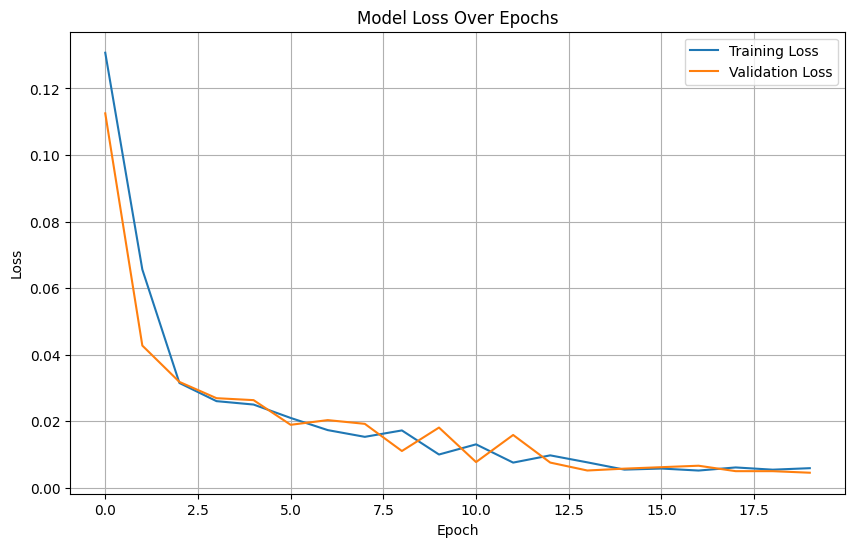

In [7]:
# 3. Train the model
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val))

# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Finally, let's evaluate the model on the test set and visualize some predictions.

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0046
Mean Squared Error on Test Data: 0.0046
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step


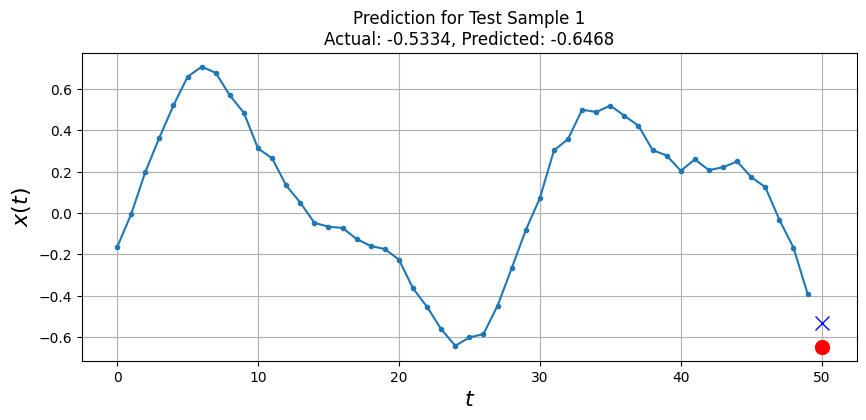

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


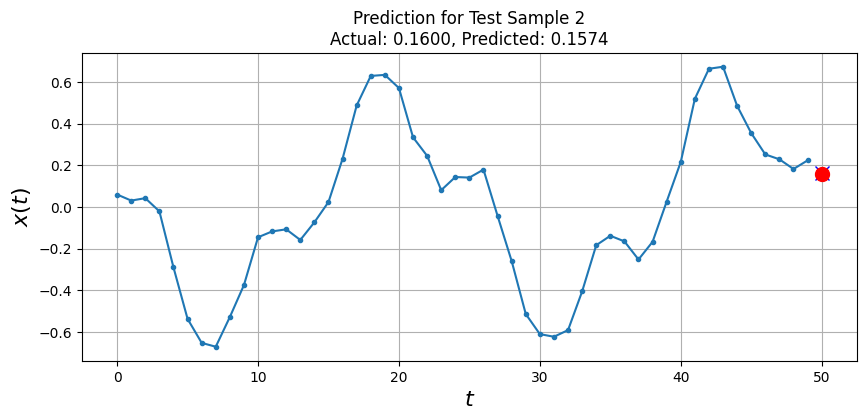

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


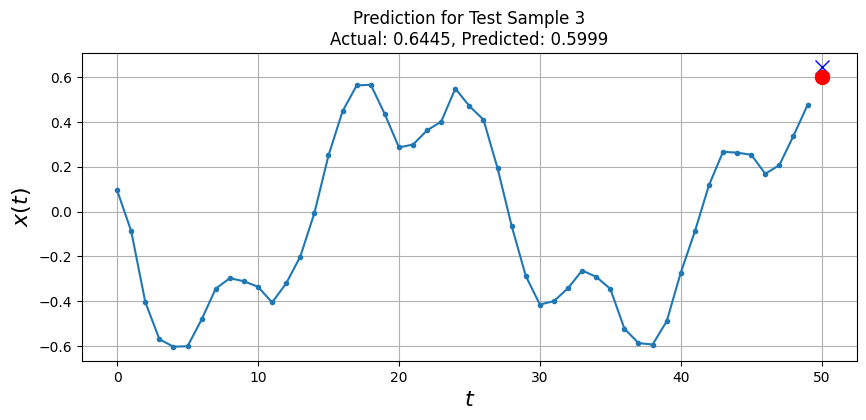

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


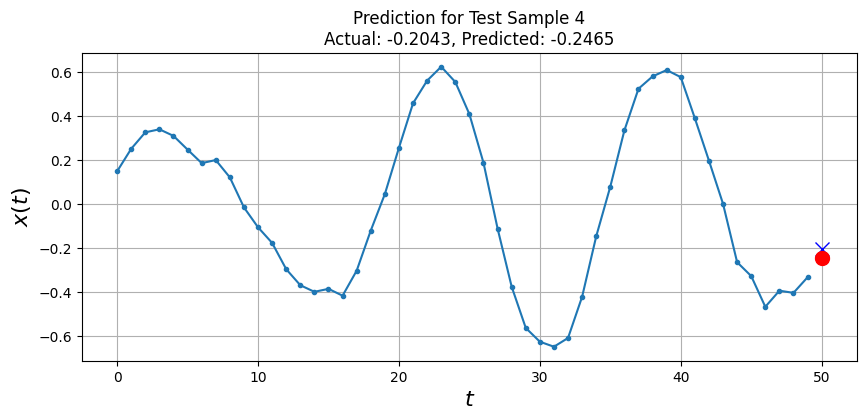

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


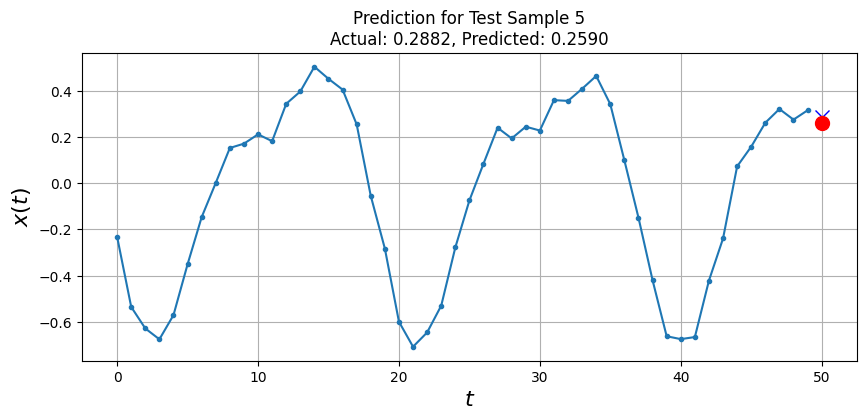

In [8]:
# 4. Evaluate the model
mse = model.evaluate(X_test, y_test)
print(f"Mean Squared Error on Test Data: {mse:.4f}")

# 5. Make predictions and visualize
def plot_series(series, y=None, y_pred=None, x_label='$t$', y_label='$x(t)$'):
    plt.plot(series, '.-')
    if y is not None:
        plt.plot(N_STEPS, y, 'bx', markersize=10)
    if y_pred is not None:
        plt.plot(N_STEPS, y_pred, 'ro', markersize=10)
    plt.xlabel(x_label, fontsize=16)
    plt.ylabel(y_label, fontsize=16)
    plt.grid(True)


# Select a few test samples to visualize
for i in range(5):
    sample_X = X_test[i:i+1]
    sample_y = y_test[i]
    sample_y_pred = model.predict(sample_X)[0][0]

    plt.figure(figsize=(10, 4))
    plot_series(sample_X[0, :, 0], sample_y[0], sample_y_pred)
    plt.title(f"Prediction for Test Sample {i+1}\nActual: {sample_y[0]:.4f}, Predicted: {sample_y_pred:.4f}")
    plt.show()